# COGS 181 Final Project
## Using Grad-CAM to analyse various CNN representations on the Tiny ImageNet dataset.

### Import necessary packages and functions.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
import cv2
import json
from tqdm.notebook import tqdm

from dataset import fix_val_folder, get_dataloaders, denormalise
from model import build_model
from train import run_training
from gradcam import GradCAM, GradCamPlusPlus, overlay_cam

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

Device: cuda


### Fix validation folder format, load data, and print out simple visualisations.

In [2]:
fix_val_folder("./tiny-imagenet-200/")
train_loader, val_loader, train_dataset, val_dataset = get_dataloaders("./tiny-imagenet-200/")
print(f"Train: {len(train_dataset):,} | Val: {len(val_dataset):,} | Classes: {len(train_dataset.classes)}")

Moved 0 images into class subdirectories.
Train: 100,000 | Val: 10,000 | Classes: 200


In [3]:
def load_class_names(data_dir="./tiny-imagenet-200/"):
    id_to_name = {}
    with open(os.path.join(data_dir, 'words.txt')) as f:
        for line in f:
            parts = line.strip().split('\t')
            id_to_name[parts[0]] = parts[1].split(',')[0]  # take first name only
    return id_to_name

id_to_name = load_class_names('./tiny-imagenet-200')

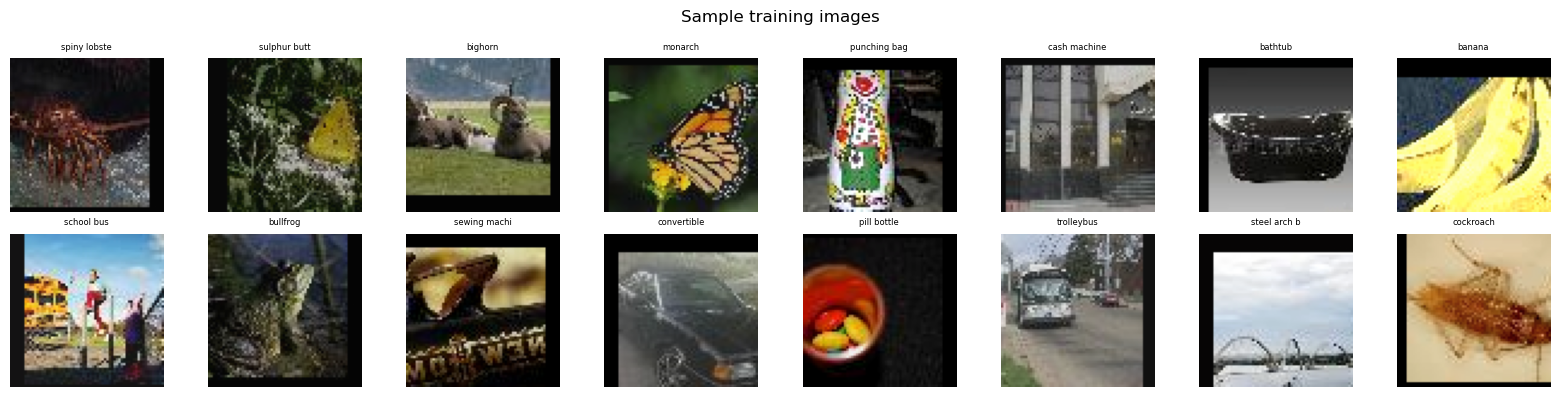

In [4]:
images, labels = next(iter(train_loader))
fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i, ax in enumerate(axes.flat):
    img = np.clip(denormalise(images[i]).permute(1, 2, 0).numpy(), 0, 1)
    ax.imshow(img)
    word_id = train_dataset.classes[labels[i]]
    ax.set_title(id_to_name.get(word_id, word_id)[:12], fontsize=6)
    ax.axis("off")
plt.suptitle("Sample training images")
plt.tight_layout()
plt.show()

### Train baseline ResNet-18.
Note: I first set num_epochs to 3 to test pipeline, before running all 30 epochs.

In [15]:
model, history = run_training(train_loader, val_loader, save_name="baseline_resnet18", device=device)

with open('./results/history_baseline.json', 'w') as f:
    json.dump(history, f)

Epoch [01/30]  Train Loss: 4.5914  Acc: 0.0628  |  Val Loss: 4.2422  Acc: 0.0930


Epoch [02/30]  Train Loss: 3.7107  Acc: 0.1690  |  Val Loss: 3.5438  Acc: 0.2086


Epoch [03/30]  Train Loss: 3.1785  Acc: 0.2620  |  Val Loss: 3.1279  Acc: 0.2829


Epoch [04/30]  Train Loss: 2.8213  Acc: 0.3314  |  Val Loss: 2.9428  Acc: 0.3137


Epoch [05/30]  Train Loss: 2.5486  Acc: 0.3860  |  Val Loss: 2.6531  Acc: 0.3774


...

Epoch [26/30]  Train Loss: 0.1374  Acc: 0.9735  |  Val Loss: 2.0893  Acc: 0.6031


Epoch [27/30]  Train Loss: 0.1146  Acc: 0.9805  |  Val Loss: 2.0913  Acc: 0.6052


Epoch [28/30]  Train Loss: 0.1015  Acc: 0.9846  |  Val Loss: 2.1022  Acc: 0.6046


Epoch [29/30]  Train Loss: 0.0940  Acc: 0.9868  |  Val Loss: 2.0821  Acc: 0.6058


Epoch [30/30]  Train Loss: 0.0920  Acc: 0.9872  |  Val Loss: 2.0804  Acc: 0.6069

Best Val Accuracy: 0.6069


### Rebuild model using best checkpoint.
Note: Prevents having to rerun training each time the kernel is restarted.

In [5]:
from model import build_model

model = build_model(architecture='resnet18', norm='batch', dropout=0.0).to(device)
model.load_state_dict(torch.load('./checkpoints/best_baseline_resnet18.pth', map_location=device))
model.eval()
print('Model loaded from checkpoint.')

with open('./results/history_baseline.json') as f:
    history = json.load(f)

Model loaded from checkpoint.


### Plot training curves.

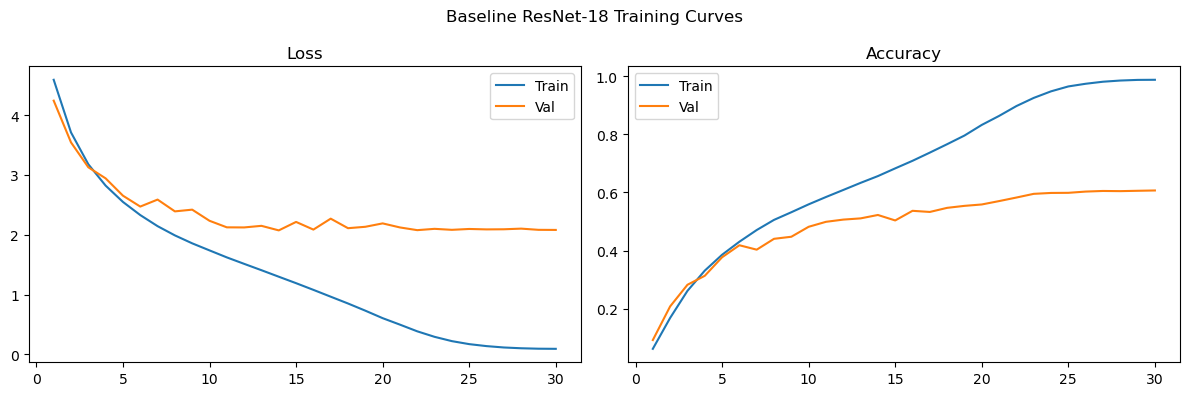

In [6]:
os.makedirs("./results", exist_ok=True)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
epochs = range(1, len(history["train_loss"]) + 1)
axes[0].plot(epochs, history["train_loss"], label="Train")
axes[0].plot(epochs, history["val_loss"],   label="Val")
axes[0].set_title("Loss"); axes[0].legend()
axes[1].plot(epochs, history["train_acc"], label="Train")
axes[1].plot(epochs, history["val_acc"],   label="Val")
axes[1].set_title("Accuracy"); axes[1].legend()
plt.suptitle("Baseline ResNet-18 Training Curves")
plt.tight_layout()
plt.savefig("./results/training_curves.png", dpi=150)
plt.show()

### Load the best checkpoint and begin Grad-CAM set up.
Note: checkpoints are saved since validation accuracy isn't always best at the last epoch. I used the final (fourth) layer to run GradCAM as it provides the best spatial information.

In [18]:
model.load_state_dict(torch.load("./checkpoints/best_baseline_resnet18.pth", map_location=device))
model.eval()

target_layer = model.layer4[-1].conv2
cam_extractor = GradCAM(model, target_layer)
cam_pp = GradCamPlusPlus(model, target_layer)

def get_val_samples(n=8):
    indices = np.random.choice(len(val_dataset), n, replace=False)
    tensors, names = [], []
    for idx in indices:
        image, label = val_dataset[idx]
        tensors.append(image.to(device))
        word_id = val_dataset.classes[label]
        names.append(id_to_name.get(word_id, word_id))
    return tensors, names

### Visualisation 1: Grad-CAM batch. Shows whether the model is learning to localise objects meaningfully or just memorising.
Note: Depicts original, overlay, and heatmap for 8 validation images.

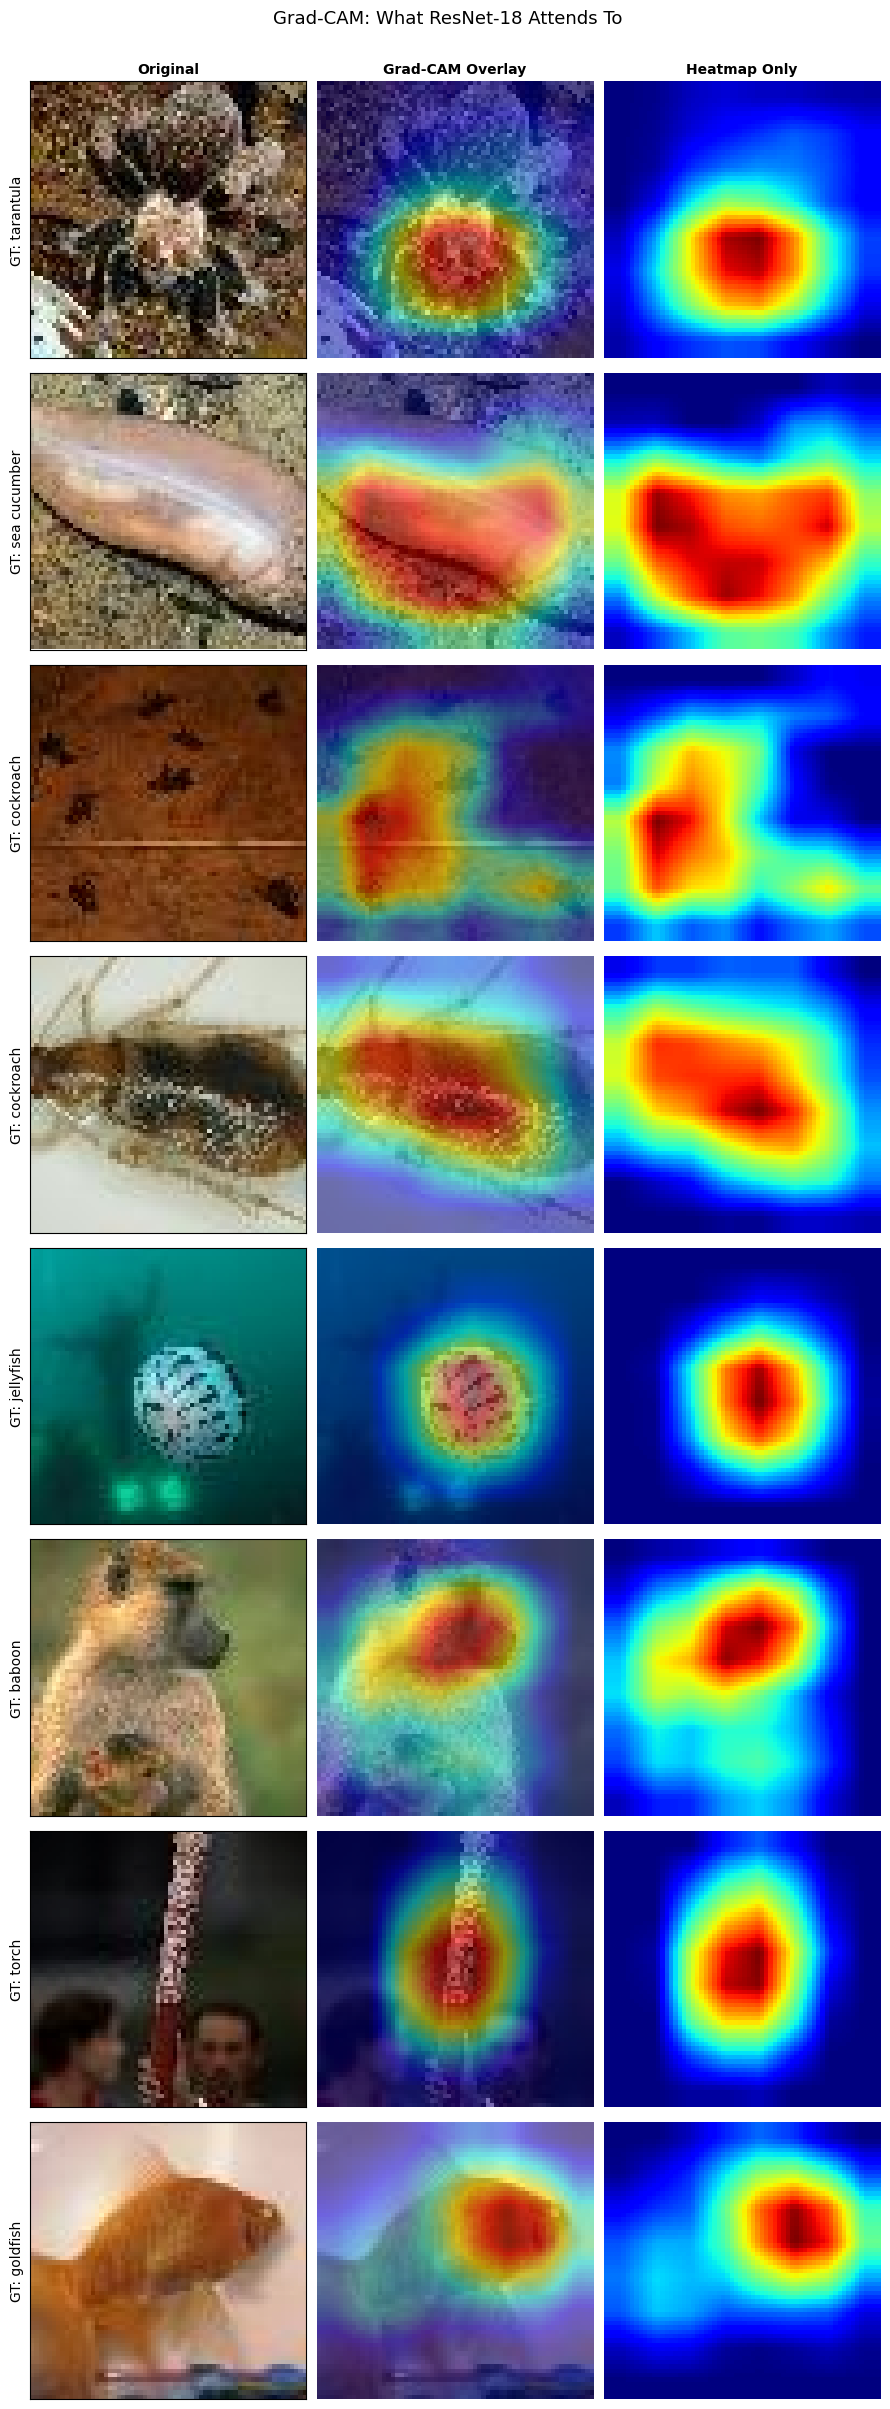

In [29]:
tensors, names = get_val_samples()

# Creats an 8x3 grid of 8 randomly sampled validation images
fig, axes = plt.subplots(8, 3, figsize=(9, 24))
for j, t in enumerate(["Original", "Grad-CAM Overlay", "Heatmap Only"]):
    axes[0, j].set_title(t, fontsize=10, fontweight="bold")

for i, (tensor, name) in enumerate(zip(tensors, names)):
    cam, pred_idx = cam_extractor.generate(tensor.unsqueeze(0))
    img_np = np.clip(denormalise(tensor).permute(1,2,0).cpu().numpy(), 0, 1)
    img_uint8 = (img_np * 255).astype("uint8")

    # Column 1
    # Shows the raw image and the ground truth label
    axes[i, 0].imshow(img_np)
    axes[i, 0].set_ylabel(f"GT: {name}", fontsize=10)
    axes[i, 0].set_xticks([])
    axes[i, 0].set_yticks([])

    # Column 2
    # Grad-CAM overlay
    # Shows the heatmap overlayed with the actual image
    # Red regions show what the model was paying attention to during its prediction
    axes[i, 1].imshow(overlay_cam(img_uint8, cam))
    axes[i, 1].set_ylabel(f"Pred: {val_dataset.classes[pred_idx]}", fontsize=7)
    axes[i, 1].axis("off")

    # Column 3
    # Raw heatmap
    # Red = high attention, Green = medium attention, Blue = low attention
    axes[i, 2].imshow(cv2.resize(cam, (64, 64)), cmap="jet")
    axes[i, 2].axis("off")

plt.suptitle("Grad-CAM: What ResNet-18 Attends To", fontsize=13, y=1.002)
plt.tight_layout()
plt.savefig("./results/gradcam_batch.png", dpi=150, bbox_inches="tight")
plt.show()

### Visualisation 2: Grad-CAM vs Grad-CAM++

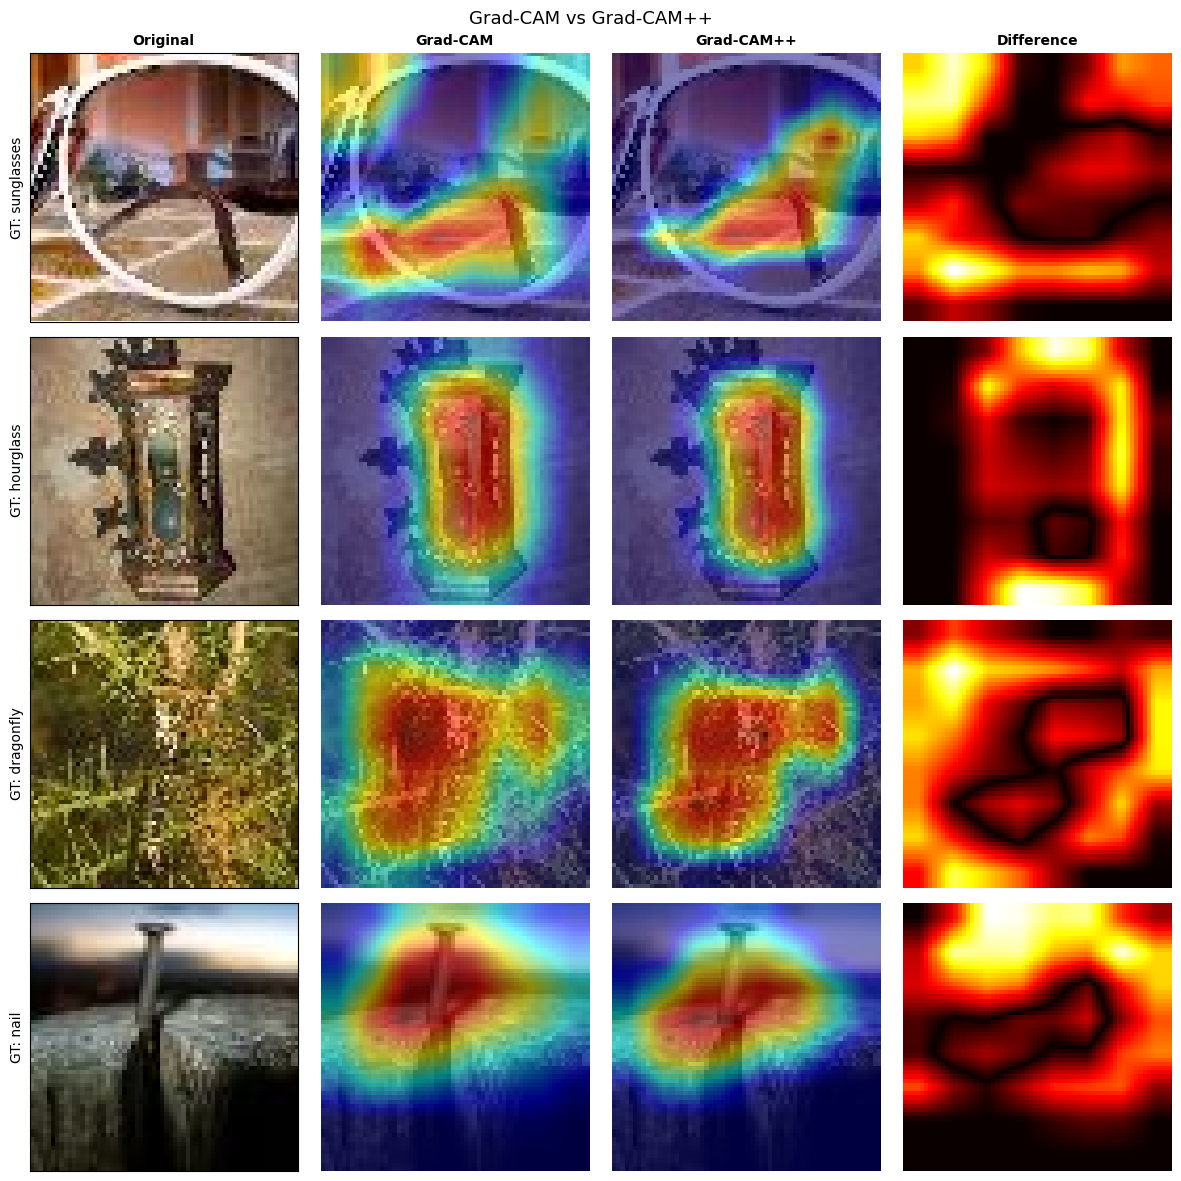

In [30]:
tensors_4, names_4 = get_val_samples(n=4)

# Creates a 4x4 grid of 4 randomly sampled validation images
fig, axes = plt.subplots(4, 4, figsize=(12, 12))
for j, t in enumerate(["Original", "Grad-CAM", "Grad-CAM++", "Difference"]):
    axes[0, j].set_title(t, fontsize=10, fontweight="bold")

for i, (tensor, name) in enumerate(zip(tensors_4, names_4)):
    cam1, _ = cam_extractor.generate(tensor.unsqueeze(0))
    cam2, _ = cam_pp.generate(tensor.unsqueeze(0))
    img_np = np.clip(denormalise(tensor).permute(1,2,0).cpu().numpy(), 0, 1)
    img_uint8 = (img_np * 255).astype("uint8")
    diff = np.abs(cv2.resize(cam1, (64,64)) - cv2.resize(cam2, (64,64)))

    # Column 1
    # Shows the raw image and the ground truth label
    axes[i, 0].imshow(img_np)
    axes[i, 0].set_ylabel(f"GT: {name}", fontsize=10)
    axes[i, 0].set_xticks([])
    axes[i, 0].set_yticks([])

    # Column 2
    # Grad-CAM overlay
    # Shows the heatmap overlayed with the actual image
    axes[i, 1].imshow(overlay_cam(img_uint8, cam1))
    axes[i, 1].axis("off")

    # Column 2
    # Grad-CAM++ overlay
    # Attention should be more tightly focused on the object itself
    axes[i, 2].imshow(overlay_cam(img_uint8, cam2))
    axes[i, 2].axis("off")

    # Column 4
    # Shows the absolute difference between both heatmaps
    # Brighter regions show where the two methods contrast
    axes[i, 3].imshow(diff, cmap="hot")
    axes[i, 3].axis("off")

plt.suptitle("Grad-CAM vs Grad-CAM++", fontsize=13)
plt.tight_layout()
plt.savefig("./results/gradcam_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

### Visualisation 3: Comparison of layer depths to show how attention changes from low-level to high-level features.
Note: Targets the final convolutional layer of each of ResNet's 4 residual blocks.

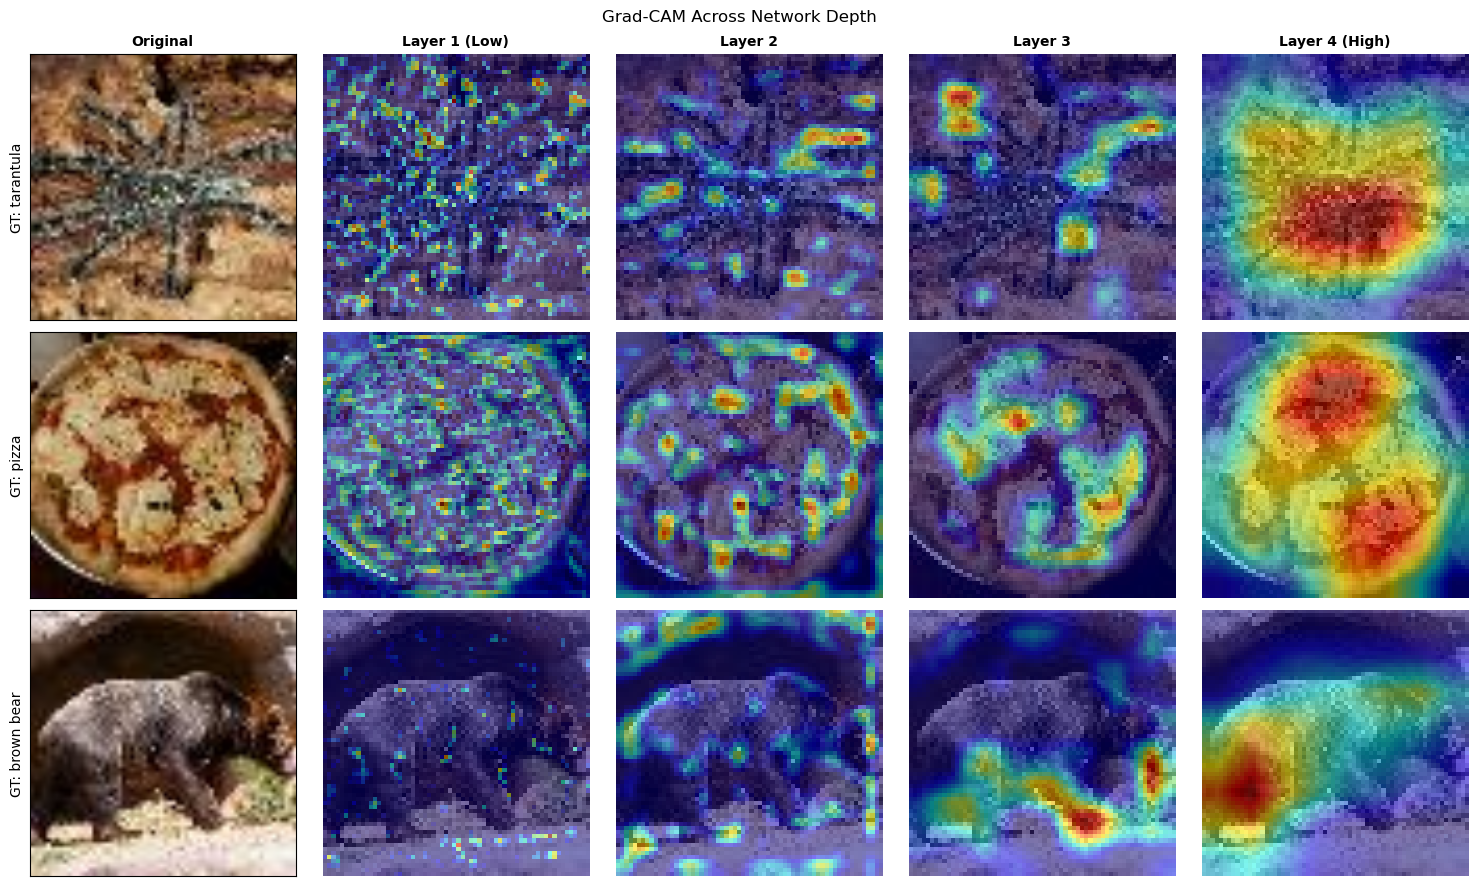

In [31]:
layers = [
    ("Layer 1 (Low)", model.layer1[-1].conv2),
    ("Layer 2", model.layer2[-1].conv2),
    ("Layer 3", model.layer3[-1].conv2),
    ("Layer 4 (High)", model.layer4[-1].conv2)
]

sample_tensors, sample_names = get_val_samples(n=3)
fig, axes = plt.subplots(3, 5, figsize=(15, 9))

# Creates a 3x5 grid of 3 randomly sampled validation images
for j, t in enumerate(["Original"] + [n for n, _ in layers]):
    axes[0, j].set_title(t, fontsize=10, fontweight="bold")

for i, (tensor, name) in enumerate(zip(sample_tensors, sample_names)):
    img_np = np.clip(denormalise(tensor).permute(1,2,0).cpu().numpy(), 0, 1)
    img_uint8 = (img_np * 255).astype("uint8")

    # Column 1
    # Shows the raw image and the ground truth label
    axes[i, 0].imshow(img_np, interpolation="bilinear")
    axes[i, 0].set_ylabel(f"GT: {name}", fontsize=10)
    axes[i, 0].set_xticks([])
    axes[i, 0].set_yticks([])

    # Columns 2-5
    # Shows Grad-CAM heatmap at each layer
    for j, (layer_name, layer) in enumerate(layers):
        cam, _ = GradCAM(model, layer).generate(tensor.unsqueeze(0))
        axes[i, j+1].imshow(overlay_cam(img_uint8, cam))
        axes[i, j+1].axis("off")

plt.suptitle("Grad-CAM Across Network Depth", fontsize=12)
plt.tight_layout()
plt.savefig("./results/layer_depth_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

### Ablation study: Run experiments by changing 4 parameters (Optimiser, LR Schedule, Normalisation, Dropout)
Note: Keep ResNet18 SGD Cosine BN as the baseline.

In [39]:
ABLATION_EPOCHS = 10
RESULTS_FILE = './results/ablation_results.json'
os.makedirs('./results', exist_ok=True)

if os.path.exists(RESULTS_FILE):
    with open(RESULTS_FILE) as f:
        ablation_results = json.load(f)
    completed = [r['Experiment'] for r in ablation_results]
    print(f'Resuming — already completed: {completed}')
else:
    ablation_results = []
    completed = []
    
EXPERIMENTS = [
    ("ResNet18 SGD Cosine BN", "resnet18", "sgd", "cosine", "batch", 0.0),
    ("ResNet18 Adam Cosine BN", "resnet18", "adam", "cosine", "batch", 0.0),
    ("ResNet18 AdamW Cosine BN", "resnet18", "adamw", "cosine", "batch", 0.0),
    ("ResNet18 SGD Step BN", "resnet18", "sgd", "step", "batch", 0.0),
    ("ResNet18 SGD Cosine GN", "resnet18", "sgd", "cosine", "group", 0.0),
    ("ResNet18 SGD Cosine LN", "resnet18", "sgd", "cosine", "layer", 0.0),
    ("ResNet18 DO0.3", "resnet18", "sgd", "cosine", "batch", 0.3),
    ("ResNet18 DO0.5", "resnet18", "sgd", "cosine", "batch", 0.5),
    ("ResNet34 SGD Cosine BN", "resnet34", "sgd", "cosine", "batch", 0.0),
    ("MobileNet SGD Cosine BN", "mobilenet", "sgd", "cosine", "batch", 0.0)
]

# Run 3 experiments at a time
BATCH_START = 6
BATCH_END = 10

for name, arch, opt, schedule, norm, dropout in EXPERIMENTS[BATCH_START: BATCH_END]:
    if name in completed:
        print(f'Skipping {name} — already completed.')
        continue

    # Separate experiments so the output is readable
    sep = '=' * 50
    print(f"\n{sep}\n{name}\n{sep}")
    _, hist = run_training(train_loader, val_loader, architecture=arch, optim=opt, schedule=schedule,
                           norm=norm, dropout=dropout, num_epochs=ABLATION_EPOCHS, 
                           save_name=name.replace(" ", "_"), device=device)

    best = max(hist["val_acc"])
    ablation_results.append({
        "Experiment": name, "Architecture": arch, "Optimiser": opt,
        "Schedule": schedule, "Norm": norm,
        "Dropout": dropout, "Best Val Acc": round(best, 4)
    })
    print(f"-> {best:.4f}")

    # Save after every experiment in case of kernel crash
    with open(RESULTS_FILE, 'w') as f:
        json.dump(ablation_results, f)
    print(f'Saved to {RESULTS_FILE}')

Resuming — already completed: ['ResNet18 SGD Cosine BN', 'ResNet18 Adam Cosine BN', 'ResNet18 AdamW Cosine BN', 'ResNet18 SGD Step BN', 'ResNet18 SGD Cosine GN', 'ResNet18 SGD Cosine LN']

ResNet18 DO0.3


Epoch [01/10]  Train Loss: 4.7313  Acc: 0.0508  |  Val Loss: 4.5216  Acc: 0.0727


Epoch [02/10]  Train Loss: 3.9356  Acc: 0.1360  |  Val Loss: 3.8662  Acc: 0.1618


Epoch [03/10]  Train Loss: 3.4254  Acc: 0.2186  |  Val Loss: 3.2191  Acc: 0.2601


Epoch [04/10]  Train Loss: 3.0480  Acc: 0.2879  |  Val Loss: 3.0641  Acc: 0.2924


...

Epoch [06/10]  Train Loss: 3.2222  Acc: 0.2518  |  Val Loss: 3.2297  Acc: 0.2498


Epoch [07/10]  Train Loss: 3.0553  Acc: 0.2827  |  Val Loss: 3.0193  Acc: 0.2905


Epoch [08/10]  Train Loss: 2.9001  Acc: 0.3123  |  Val Loss: 2.9575  Acc: 0.3071


Epoch [09/10]  Train Loss: 2.7669  Acc: 0.3373  |  Val Loss: 2.7864  Acc: 0.3420


Epoch [10/10]  Train Loss: 2.6818  Acc: 0.3539  |  Val Loss: 2.7515  Acc: 0.3487

Best Val Accuracy: 0.3487
-> 0.3487
Saved to ./results/ablation_results.json


### Display final validation accuracies of each model.

              Experiment  Best Val Acc
  ResNet34 SGD Cosine BN        0.5531
  ResNet18 SGD Cosine BN        0.5521
 ResNet18 Adam Cosine BN        0.5470
          ResNet18 DO0.3        0.5361
ResNet18 AdamW Cosine BN        0.5169
          ResNet18 DO0.5        0.5143
    ResNet18 SGD Step BN        0.4637
  ResNet18 SGD Cosine GN        0.3604
 MobileNet SGD Cosine BN        0.3487
  ResNet18 SGD Cosine LN        0.3111


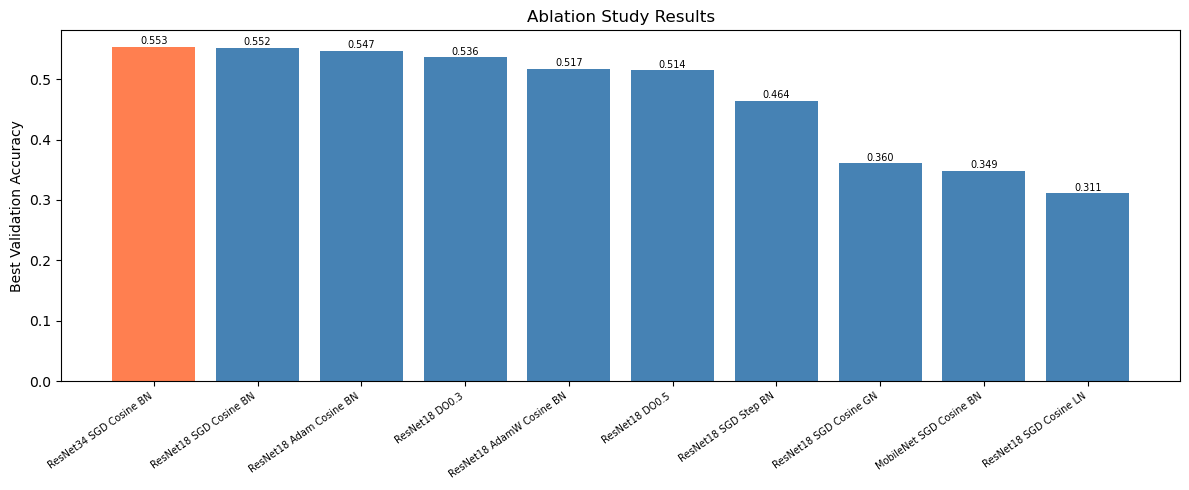

In [7]:
with open('./results/ablation_results.json') as f:
    ablation_results = json.load(f)

df = pd.DataFrame(ablation_results).sort_values("Best Val Acc", ascending=False)
df.to_csv("./results/ablation_summary.csv", index=False)
print(df[["Experiment", "Best Val Acc"]].to_string(index=False))

# Set baseline bars to red and everything else to blue to make comparisons
fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(df["Experiment"], df["Best Val Acc"], color=["coral"] + ["steelblue"] * (len(df) - 1))
ax.set_ylabel("Best Validation Accuracy")
ax.set_title("Ablation Study Results")
ax.set_xticks(range(len(df)))
ax.set_xticklabels(df["Experiment"], rotation=35, ha="right", fontsize=7)
for bar, val in zip(bars, df["Best Val Acc"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001, f"{val:.3f}", 
            ha="center", va="bottom", fontsize=7)

plt.tight_layout()
plt.savefig("./results/ablation_chart.png", dpi=150, bbox_inches="tight")
plt.show()

As can be seen above, over 10 epochs, ResNet34 with SGD, cosine annealing, and batch norm had the best performance. Meanwhile, ResNet18 with SGD, cosine annealing, and layer norm had the worst performance. To conduct an analysis on how both models learn features, I will train each on 30 epochs and run the Grad-CAM analysis.

Note: To increase ResNet-34's performance, I added a dropout rate of 0.4.

In [9]:
best_model, best_history = run_training(train_loader, val_loader, architecture="resnet34", optim="sgd", 
                                        schedule="cosine", norm="batch", dropout=0.4, num_epochs=30, 
                                        save_name="best_model", device=device)

with open("./results/history_best_model.json", "w") as f:
    json.dump(best_history, f)

print(f'Best Val Acc: {max(best_history["val_acc"]):.4f}')

KeyboardInterrupt: 

In [ ]:
worst_model, worst_history = run_training(train_loader, val_loader, architecture="resnet18", optim="sgd",
                                          schedule="cosine", norm="layer", dropout=0.0, num_epochs=30,
                                          save_name="worst_model", device=device)

with open("./results/history_worst_model.json", "w") as f:
    json.dump(worst_history, f)

print(f'Worst Val Acc: {max(worst_history["val_acc"]):.f};)